# Lesson 3: Intro to Neural Networks, Deep Learning and NLP

## Introduction to Neural Networks for Stock Price Prediction

### Theory Behind Neural Networks

Neural networks form the foundation of deep learning. While linear regression is constrained to fitting straight lines or flat hyperplanes, neural networks use interconnected layers of mathematical nodes (often called "neurons") to model highly complex, non-linear relationships within data.

**Basic Formula:** A neural network is built from individual neurons. For a single artificial neuron, the transformation happens in two distinct steps: a linear combination followed by a non-linear activation.

First, it calculates the weighted sum of its inputs:$$z = \sum_{i=1}^{n} w_i x_i + b$$

Next, it passes that sum through an activation function:$$a = \sigma(z)$$

Where:

- $x_1, x_2, ..., x_n$ are the inputs (your features).

- $w_1, w_2, ..., w_n$ are the weights, determining the importance of each corresponding input.
- $b$ is the bias term, which shifts the activation threshold (conceptually similar to the y-intercept in linear regression).
- $z$ is the resulting linear combination.
- $\sigma$ is the activation function (e.g., ReLU, Sigmoid, or Tanh). This is the crucial ingredient that allows the network to learn non-linear patterns.
- $a$ is the final output (activation) of that specific neuron.

The primary goal of a neural network is to find the optimal set of weights and biases across all its layers that minimizes a specific "loss function" (such as Mean Squared Error for regression, or Cross-Entropy for classification).

The network learns this through a two-step iterative process:

1. Forward Propagation: Passing data through the network to make a prediction and calculating the error.
2. Backpropagation: Using calculus (the chain rule) to calculate the gradient of the loss function with respect to every weight and bias, and then updating those parameters using an optimization algorithm like Gradient Descent.


**Application:**

Neural networks are used when the relationships in your data are too complex or subtle for traditional linear models. In quantitative finance, they are heavily applied to process unstructured "alternative data" (like using Natural Language Processing on financial news or earnings calls), recognizing complex patterns in order-book data, and modeling non-linear phenomena like volatility clustering.


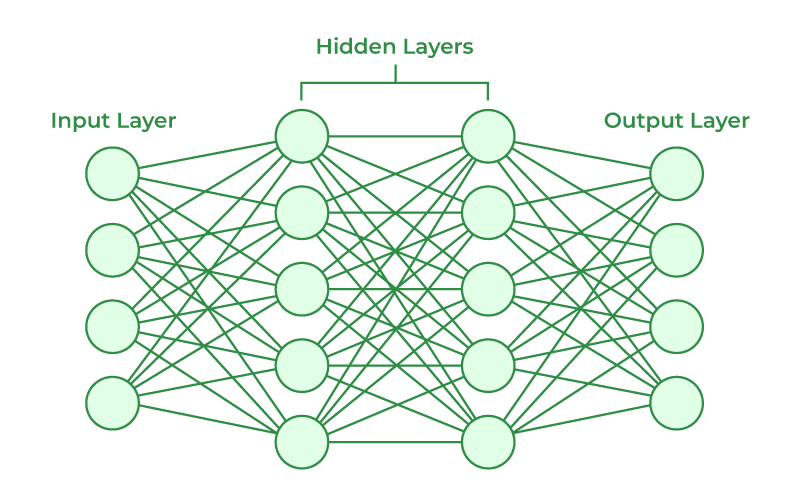

In [ ]:
from IPython.display import Image
Image(filename = "Neural-Networks-Architecture.png", width=900, height=600)

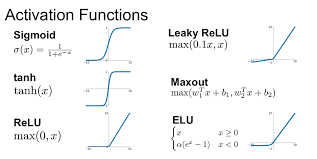

In [ ]:
from IPython.display import Image
Image(filename = "activation.png", width=900, height=450)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
import yfinance as yf
# Re-fetch data to ensure a clean state from yfinance
ticker = 'AAPL'
start_date = '2020-01-01'
end_date = '2026-01-01'
data = yf.download(ticker, start=start_date, end=end_date)
data.head()

/tmp/ipython-input-2368419320.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [ ]:
import pandas as pd
# Ensure data is a copy to avoid SettingWithCopyWarning
data = data.copy()

# Flatten MultiIndex columns if they exist
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
    data.columns.name = None
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [ ]:
# Calculate daily percentage change for returns
data['Return'] = data['Close'].pct_change()

# Create the target variable: 1 if next day's price moves up, 0 otherwise
data['Target'] = (data['Return'].shift(-1) > 0).astype(int)

data.dropna(inplace = True)

data.head()

,Close,High,Low,Open,Volume,Return,Target
Date,,,,,,,
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,-0.009722,1
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.007968,0
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000,-0.004703,1
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,0.016086,1
2020-01-09,74.637497,74.830337,73.810684,74.061375,170108400,0.021241,1


In [ ]:
# Use 'Open', 'High', 'Low', 'Close', 'Volume', and 'Return' as initial features
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return']

# Add a window of past returns as features
window = 5 # Number of past days to consider
for i in range(1, window + 1):
    data[f'Return_lag_{i}'] = data['Return'].shift(i)
    features.append(f'Return_lag_{i}')

data.head()

,Close,High,Low,Open,Volume,Return,Target,Return_lag_1,Return_lag_2,Return_lag_3,Return_lag_4,Return_lag_5
Date,,,,,,,,,,,,
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,-0.009722,1,NaN,NaN,NaN,NaN,NaN
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.007968,0,-0.009722,NaN,NaN,NaN,NaN
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000,-0.004703,1,0.007968,-0.009722,NaN,NaN,NaN
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,0.016086,1,-0.004703,0.007968,-0.009722,NaN,NaN
2020-01-09,74.637497,74.830337,73.810684,74.061375,170108400,0.021241,1,0.016086,-0.004703,0.007968,-0.009722,NaN


In [ ]:
# Drop rows with NaN values resulting from pct_change or shifting
data.dropna(inplace=True)

X = data[features]
y = data['Target']
X.head()

,Open,High,Low,Close,Volume,Return,Return_lag_1,Return_lag_2,Return_lag_3,Return_lag_4,Return_lag_5
Date,,,,,,,,,,,
2020-01-10,74.871295,75.370278,74.304817,74.806206,140644800,0.002260,0.021241,0.016086,-0.004703,0.007968,-0.009722
2020-01-13,75.122003,76.430923,75.003882,76.404404,121532000,0.021365,0.002260,0.021241,0.016086,-0.004703,0.007968
2020-01-14,76.341760,76.551476,75.249786,75.372719,161954400,-0.013503,0.021365,0.002260,0.021241,0.016086,-0.004703
2020-01-15,75.172645,76.052490,74.618217,75.049706,121923600,-0.004286,-0.013503,0.021365,0.002260,0.021241,0.016086
2020-01-16,75.592085,76.100712,75.230504,75.989822,108829200,0.012527,-0.004286,-0.013503,0.021365,0.002260,0.021241


In [ ]:
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets withour shuffling
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(type(X_train_scaled))
X_train_scaled

<class 'numpy.ndarray'>


array([[-1.90257122, -1.92439814, -1.88608554, ..., -0.28940206,
         0.33548209, -0.53633972],
       [-1.89606548, -1.89699262, -1.86785638, ...,  0.73512028,
        -0.28910784,  0.33559386],
       [-1.86441348, -1.89387773, -1.86144405, ...,  0.98915104,
         0.73560956, -0.28895838],
       ...,
       [ 2.17704653,  2.22448947,  2.19615575, ..., -0.16497127,
         0.76578303,  0.8499312 ],
       [ 2.12522936,  2.0866425 ,  2.13061346, ..., -0.37821634,
        -0.16465336,  0.76586884],
       [ 2.17240667,  2.13105181,  2.14823006, ...,  0.75451992,
        -0.37793903, -0.1645114 ]])

In [ ]:
import torch
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # Unsqueeze for binary classification
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print("Data splitting, scaling, and conversion to PyTorch tensors complete.")
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

Data splitting, scaling, and conversion to PyTorch tensors complete.
X_train_tensor shape: torch.Size([1201, 11])
y_train_tensor shape: torch.Size([1201, 1])
X_test_tensor shape: torch.Size([301, 11])
y_test_tensor shape: torch.Size([301, 1])


In [ ]:
import torch.nn as nn
# Define Model
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid() # For binary classification output between 0 and 1

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

In [ ]:
# Define hyperparameters for the FFNN
input_size = X_train_tensor.shape[1] # Number of features
hidden_size = 64 # You can adjust this
output_size = 1 # Binary classification (up or down)
print(input_size)

11


In [ ]:
# Instantiate the FFNN model
model = FFNN(input_size, hidden_size, output_size)

print("FFNN model architecture:")
print(model)
print("Input size:", input_size)
print("Hidden size:", hidden_size)
print("Output size:", output_size)

FFNN model architecture:
FFNN(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Input size: 11
Hidden size: 64
Output size: 1


In [ ]:
import torch.optim as optim
# Define loss function and optimizer
criterion = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Other possibility: Stochastic Gradient Descent
# optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Training the FFNN model
epochs = 100

for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("Training complete.")

Epoch [10/100], Loss: 0.7030
Epoch [20/100], Loss: 0.6934
Epoch [30/100], Loss: 0.6891
Epoch [40/100], Loss: 0.6864
Epoch [50/100], Loss: 0.6843
Epoch [60/100], Loss: 0.6824
Epoch [70/100], Loss: 0.6807
Epoch [80/100], Loss: 0.6791
Epoch [90/100], Loss: 0.6775
Epoch [100/100], Loss: 0.6760
Training complete.


In [ ]:
model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for evaluation
    y_pred_tensor = model(X_test_tensor)
    y_pred_binary = (y_pred_tensor > 0.5).float() # Convert probabilities to binary predictions

# Calculate accuracy
correct_predictions = (y_pred_binary == y_test_tensor).sum().item()
total_predictions = y_test_tensor.numel()
accuracy = correct_predictions / total_predictions

print(f"Model Accuracy on Test Set: {accuracy:.4f}")

Model Accuracy on Test Set: 0.5349


## Deep Learning with LSTMs for Enhanced Stock Prediction

### Why Use LSTMs Instead of Standard Neural Networks?

If standard Feed-Forward Neural Networks (FFNNs) are so powerful, why do we need a new architecture for stock prediction?

The answer lies in **time**.

* **The Problem with FFNNs:** A standard neural network processes each row of data in isolation. If you feed it today's stock data, it makes a prediction without any "memory" of yesterday, the day before, or the overall trend. It assumes all inputs are completely independent.
* **The Power of LSTMs:** In quantitative finance, the sequence of events is everything. Long Short-Term Memory networks (LSTMs) are a specialized type of Recurrent Neural Network (RNN) designed exclusively for sequential and time-series data. They contain internal memory mechanisms (cell states and hidden states) that allow them to remember long-term dependencies and patterns over time.


When an LSTM looks at today's price, it evaluates it using the context of the past few days, making it far superior for forecasting financial markets. Let's build one!

In [ ]:
data[0:5]

,Close,High,Low,Open,Volume,Return,Target,Return_lag_1,Return_lag_2,Return_lag_3,Return_lag_4,Return_lag_5
Date,,,,,,,,,,,,
2020-01-10,74.806206,75.370278,74.304817,74.871295,140644800,0.002260,1,0.021241,0.016086,-0.004703,0.007968,-0.009722
2020-01-13,76.404404,76.430923,75.003882,75.122003,121532000,0.021365,0,0.002260,0.021241,0.016086,-0.004703,0.007968
2020-01-14,75.372719,76.551476,75.249786,76.341760,161954400,-0.013503,0,0.021365,0.002260,0.021241,0.016086,-0.004703
2020-01-15,75.049706,76.052490,74.618217,75.172645,121923600,-0.004286,1,-0.013503,0.021365,0.002260,0.021241,0.016086
2020-01-16,75.989822,76.100712,75.230504,75.592085,108829200,0.012527,1,-0.004286,-0.013503,0.021365,0.002260,0.021241


In [ ]:
sequence_length = window # Use the same window as for lagged features

# Function to create sequences for LSTM
def create_sequences(data, sequence_length):
    xs = []
    for i in range(len(data) - sequence_length + 1):
        x = data[i:(i + sequence_length)]
        xs.append(x)
    return np.array(xs)


# Restructure X_train_scaled and X_test_scaled into sequences
X_train_lstm = create_sequences(X_train_scaled, sequence_length)
X_test_lstm = create_sequences(X_test_scaled, sequence_length)

# Adjust y_train and y_test to align with the sequences
y_train_lstm = y_train.iloc[sequence_length - 1:].values # Target corresponds to the last element of the sequence
y_test_lstm = y_test.iloc[sequence_length - 1:].values # Target corresponds to the last element of the sequence

np.shape(X_train_lstm)

(1197, 5, 11)

In [ ]:
# Convert to PyTorch tensors
X_train_lstm_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_lstm_tensor = torch.tensor(y_train_lstm, dtype=torch.float32).unsqueeze(1)
X_test_lstm_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_lstm_tensor = torch.tensor(y_test_lstm, dtype=torch.float32).unsqueeze(1)

print("Data restructured into sequences for LSTM and converted to PyTorch tensors.")
print("X_train_lstm_tensor shape:", X_train_lstm_tensor.shape)
print("y_train_lstm_tensor shape:", y_train_lstm_tensor.shape)
print("X_test_lstm_tensor shape:", X_test_lstm_tensor.shape)
print("y_test_lstm_tensor shape:", y_test_lstm_tensor.shape)


Data restructured into sequences for LSTM and converted to PyTorch tensors.
X_train_lstm_tensor shape: torch.Size([1197, 5, 11])
y_train_lstm_tensor shape: torch.Size([1197, 1])
X_test_lstm_tensor shape: torch.Size([297, 5, 11])
y_test_lstm_tensor shape: torch.Size([297, 1])


In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Pass through LSTM layer
        out, _ = self.lstm(x, (h0, c0)) # out: tensor of shape (batch_size, seq_length, hidden_size)

        # Take the output of the last time step
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)
        return out

In [ ]:
# Define hyperparameters for the LSTM model
input_size_lstm = X_train_lstm_tensor.shape[2] # Number of features per time step
hidden_size_lstm = 50 # You can adjust this
num_layers_lstm = 2 # Number of LSTM layers
output_size_lstm = 1 # Binary classification (up or down)

# Instantiate the LSTM model
lstm_model = LSTM(input_size_lstm, hidden_size_lstm, num_layers_lstm, output_size_lstm)

print("LSTM model architecture:")
print(lstm_model)
print("Input size:", input_size_lstm)
print("Hidden size:", hidden_size_lstm)
print("Number of layers:", num_layers_lstm)
print("Output size:", output_size_lstm)

LSTM model architecture:
LSTM(
  (lstm): LSTM(11, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Input size: 11
Hidden size: 50
Number of layers: 2
Output size: 1


In [ ]:
# Define loss function and optimizer for the LSTM model
criterion_lstm = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.001)

In [ ]:
# Training the LSTM model
epochs_lstm = 100

for epoch in range(epochs_lstm):
    # Forward pass
    outputs_lstm = lstm_model(X_train_lstm_tensor)
    loss_lstm = criterion_lstm(outputs_lstm, y_train_lstm_tensor)

    # Backward and optimize
    optimizer_lstm.zero_grad()
    loss_lstm.backward()
    optimizer_lstm.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs_lstm}], Loss: {loss_lstm.item():.4f}')

print("LSTM Model Training complete.")

Epoch [10/100], Loss: 0.6906
Epoch [20/100], Loss: 0.6885
Epoch [30/100], Loss: 0.6854
Epoch [40/100], Loss: 0.6810
Epoch [50/100], Loss: 0.6748
Epoch [60/100], Loss: 0.6676
Epoch [70/100], Loss: 0.6588
Epoch [80/100], Loss: 0.6474
Epoch [90/100], Loss: 0.6345
Epoch [100/100], Loss: 0.6175
LSTM Model Training complete.


In [ ]:
lstm_model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for evaluation
    y_pred_lstm_tensor = lstm_model(X_test_lstm_tensor)
    y_pred_lstm_binary = (y_pred_lstm_tensor > 0.5).float() # Convert probabilities to binary predictions

# Calculate accuracy
correct_predictions_lstm = (y_pred_lstm_binary == y_test_lstm_tensor).sum().item()
total_predictions_lstm = y_test_lstm_tensor.numel()
accuracy_lstm = correct_predictions_lstm / total_predictions_lstm

print(f"LSTM Model Accuracy on Test Set: {accuracy_lstm:.4f}")

LSTM Model Accuracy on Test Set: 0.5320


### Understanding the LSTM Implementation

Now that we have built and trained our LSTM, let's break down what is actually happening under the hood and why it differs from the standard Feed-Forward Neural Network (FFNN) we used earlier:

1. **The 3D Input Shape:** Standard neural networks take a 2D input `(Batch Size, Features)`. However, an LSTM requires a 3D tensor: `(Batch Size, Sequence Length, Features)`. By using the `create_sequences` function, we packaged our data into "rolling windows" of 5 days. This allows the model to look at a sequence of recent history rather than just a single isolated snapshot in time.
2. **Hidden State ($h_0$) and Cell State ($c_0$):** In the `forward` method, you'll notice we initialize two matrices with zeros.
   * The **Cell State ($c_0$)** acts as the "long-term memory" conveyor belt of the network, selectively carrying relevant information across the entire 5-day sequence.
   * The **Hidden State ($h_0$)** is the "short-term memory", updating at each daily step to reflect the immediate context.
3. **Processing the Sequence:** As the data passes through the `nn.LSTM` layer, it processes the 5-day window step-by-step. Because we are only trying to predict the *next* day's movement, we don't need the outputs from days 1 through 4. This is why we slice the output using `out[:, -1, :]`—we are explicitly telling the network to take the final learned representation at the end of the sequence and pass *that* into our final classification layer.

## Introduction to NLP and Sentiment Analysis Model

### Why Sentiment Analysis? The Role of Alternative Data

Up until now, we have only fed our models **numerical data** (Open, High, Low, Close, Volume). However, modern algorithmic trading relies heavily on **alternative data**, particularly unstructured human language.

Markets are driven by human psychology, news, and real-world events. A sudden CEO resignation, an unexpected Federal Reserve announcement, or an escalating geopolitical conflict can crash a stock long before those numbers reflect on a balance sheet.

* **Natural Language Processing (NLP):** This is the branch of AI that gives computers the ability to read, understand, and derive meaning from human languages.
* **Sentiment Analysis:** A specific NLP technique used to determine the emotional tone behind a body of text. It classifies text (like a news headline, earnings call transcript, or a tweet) as positive, negative, or neutral.


By building a Sentiment Analysis model, we can program our trading algorithms to instantly "read" thousands of news headlines and gauge market mood in real-time. This gives quantitative analysts a massive edge over strategies that rely on price history alone. Let's see how we can preprocess text to train a model to do exactly this.

In [ ]:
import pandas as pd
import numpy as np
import string
from sklearn.model_selection import train_test_split
import torch

# 1. Create a mock dataset of financial news headlines with sentiment labels
headlines = [
    "Apple stock soars after record earnings report",
    "Oil prices plummet due to global supply glut",
    "Federal Reserve hints at interest rate hike",
    "Tech giant acquires leading AI startup for billions",
    "Inflation concerns weigh on consumer spending",
    "New government policy boosts renewable energy sector",
    "Market volatility expected amid geopolitical tensions",
    "Strong retail sales data signals economic recovery",
    "Company X misses revenue targets, stock drops significantly",
    "Innovations in biotech promise breakthroughs in healthcare",
    "Global trade tensions escalate, impacting supply chains",
    "Housing market cools as interest rates rise",
    "E-commerce giant expands into new international markets",
    "Positive analyst reports drive up stock valuations",
    "Cryptocurrency market experiences sharp correction",
    "Manufacturing output exceeds expectations, driving growth",
    "Unemployment figures remain stubbornly high",
    "Luxury brand reports strong holiday sales",
    "Supply chain disruptions continue to pressure industries",
    "New tech regulations could impact big tech profits"
]
sentiments = [
    "positive", "negative", "neutral", "positive", "negative",
    "positive", "negative", "positive", "negative", "positive",
    "negative", "negative", "positive", "positive", "negative",
    "positive", "negative", "positive", "negative", "neutral"
]

df_sentiment = pd.DataFrame({
    'headline': headlines,
    'sentiment': sentiments
})

print("Mock financial news sentiment dataset created:")
print(df_sentiment.head())

Mock financial news sentiment dataset created:
                                            headline sentiment
0     Apple stock soars after record earnings report  positive
1       Oil prices plummet due to global supply glut  negative
2        Federal Reserve hints at interest rate hike   neutral
3  Tech giant acquires leading AI startup for bil...  positive
4      Inflation concerns weigh on consumer spending  negative


In [ ]:
import string

# Function to clean and tokenize text
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    return text.split() # Tokenize

# Apply cleaning and tokenization
df_sentiment['cleaned_headline'] = df_sentiment['headline'].apply(clean_text)

# 2. Define a vocabulary from all unique words
all_words = [word for tokens in df_sentiment['cleaned_headline'] for word in tokens]
vocabulary = sorted(list(set(all_words)))
vocabulary_to_idx = {word: idx + 1 for idx, word in enumerate(vocabulary)} # +1 for padding index 0
vocabulary_to_idx['<pad>'] = 0 # Add padding token

# 3. Map each word to its index and pad/truncate sequences
max_sequence_length = 15 # Fixed length for sequences

def encode_and_pad(tokens, vocab_to_idx, max_len):
    encoded = [vocab_to_idx[word] for word in tokens if word in vocab_to_idx]
    if len(encoded) < max_len:
        padded = encoded + [vocab_to_idx['<pad>']] * (max_len - len(encoded))
    else:
        padded = encoded[:max_len]
    return padded

df_sentiment['encoded_headline'] = df_sentiment['cleaned_headline'].apply(lambda x: encode_and_pad(x, vocabulary_to_idx, max_sequence_length))

# 4. Convert sentiment labels to numerical representations
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_sentiment['sentiment_encoded'] = df_sentiment['sentiment'].map(sentiment_map)

print("Text preprocessing complete. Vocabulary size:", len(vocabulary_to_idx))
print("Sample of preprocessed data:")
print(df_sentiment[['headline', 'cleaned_headline', 'encoded_headline', 'sentiment', 'sentiment_encoded']].head())

Text preprocessing complete. Vocabulary size: 118
Sample of preprocessed data:
                                            headline  \
0     Apple stock soars after record earnings report   
1       Oil prices plummet due to global supply glut   
2        Federal Reserve hints at interest rate hike   
3  Tech giant acquires leading AI startup for bil...   
4      Inflation concerns weigh on consumer spending   

                                    cleaned_headline  \
0  [apple, stock, soars, after, record, earnings,...   
1  [oil, prices, plummet, due, to, global, supply...   
2  [federal, reserve, hints, at, interest, rate, ...   
3  [tech, giant, acquires, leading, ai, startup, ...   
4  [inflation, concerns, weigh, on, consumer, spe...   

                                    encoded_headline sentiment  \
0  [6, 103, 100, 2, 84, 31, 89, 0, 0, 0, 0, 0, 0,...  positive   
1  [72, 79, 75, 30, 110, 46, 106, 47, 0, 0, 0, 0,...  negative   
2  [41, 91, 53, 8, 62, 82, 52, 0, 0, 0, 0, 0, 0, 

In [ ]:
from sklearn.model_selection import train_test_split

# 5. Split the processed data into training and testing sets
# X will be the encoded headline sequences, y will be the encoded sentiments
X_sentiment = np.array(df_sentiment['encoded_headline'].tolist())
y_sentiment = df_sentiment['sentiment_encoded'].values

X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(
    X_sentiment, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

print("Data split into training and testing sets:")
print("X_train_sentiment shape:", X_train_sentiment.shape)
print("y_train_sentiment shape:", y_train_sentiment.shape)
print("X_test_sentiment shape:", X_test_sentiment.shape)
print("y_test_sentiment shape:", y_test_sentiment.shape)

Data split into training and testing sets:
X_train_sentiment shape: (16, 15)
y_train_sentiment shape: (16,)
X_test_sentiment shape: (4, 15)
y_test_sentiment shape: (4,)


In [ ]:
import torch

# 6. Convert the training and testing data into PyTorch tensors
X_train_sentiment_tensor = torch.tensor(X_train_sentiment, dtype=torch.long)
y_train_sentiment_tensor = torch.tensor(y_train_sentiment, dtype=torch.long)
X_test_sentiment_tensor = torch.tensor(X_test_sentiment, dtype=torch.long)
y_test_sentiment_tensor = torch.tensor(y_test_sentiment, dtype=torch.long)

print("Data converted to PyTorch tensors:")
print("X_train_sentiment_tensor shape:", X_train_sentiment_tensor.shape)
print("y_train_sentiment_tensor shape:", y_train_sentiment_tensor.shape)
print("X_test_sentiment_tensor shape:", X_test_sentiment_tensor.shape)
print("y_test_sentiment_tensor shape:", y_test_sentiment_tensor.shape)


Data converted to PyTorch tensors:
X_train_sentiment_tensor shape: torch.Size([16, 15])
y_train_sentiment_tensor shape: torch.Size([16])
X_test_sentiment_tensor shape: torch.Size([4, 15])
y_test_sentiment_tensor shape: torch.Size([4])


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Define a PyTorch neural network class for sentiment analysis
class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes):
        super(SentimentClassifier, self).__init__()
        # 2. Embedding layer to convert word indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Flatten the embeddings (sequence_length * embedding_dim) before passing to linear layer
        # input_size for the first linear layer will be max_sequence_length * embedding_dim
        self.fc1 = nn.Linear(max_sequence_length * embedding_dim, hidden_size)
        self.relu = nn.ReLU()
        # 3. Final linear layer to output num_classes
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, max_sequence_length)
        embedded = self.embedding(x) # embedded shape: (batch_size, max_sequence_length, embedding_dim)
        # Flatten the embedded output for the linear layer
        # Reshapes to (batch_size, max_sequence_length * embedding_dim)
        flattened = embedded.view(embedded.size(0), -1)

        out = self.fc1(flattened)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Define hyperparameters for the Sentiment Analysis Model
vocab_size = len(vocabulary_to_idx) # Size of the vocabulary including padding
embedding_dim = 100 # Dimension of the word embeddings (can be adjusted)
hidden_size_sentiment = 64 # Hidden layer size (can be adjusted)
num_classes = len(sentiment_map) # Number of sentiment classes (0, 1, 2 for negative, neutral, positive)

# 4. Instantiate the sentiment analysis model
sentiment_model = SentimentClassifier(vocab_size, embedding_dim, hidden_size_sentiment, num_classes)

print("Sentiment Analysis Model Architecture:")
print(sentiment_model)
print(f"Vocabulary size: {vocab_size}")
print(f"Embedding dimension: {embedding_dim}")
print(f"Hidden layer size: {hidden_size_sentiment}")
print(f"Number of classes: {num_classes}")

Sentiment Analysis Model Architecture:
SentimentClassifier(
  (embedding): Embedding(118, 100)
  (fc1): Linear(in_features=1500, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)
Vocabulary size: 118
Embedding dimension: 100
Hidden layer size: 64
Number of classes: 3


In [ ]:
import torch.optim as optim
import torch.nn as nn

# 5. Define the loss function and optimizer
criterion_sentiment = nn.CrossEntropyLoss() # For multi-class classification
optimizer_sentiment = optim.Adam(sentiment_model.parameters(), lr=0.001)

# 6. Train the model
epochs_sentiment = 50 # You can adjust this

for epoch in range(epochs_sentiment):
    # Forward pass
    outputs_sentiment = sentiment_model(X_train_sentiment_tensor)
    loss_sentiment = criterion_sentiment(outputs_sentiment, y_train_sentiment_tensor)

    # Backward and optimize
    optimizer_sentiment.zero_grad()
    loss_sentiment.backward()
    optimizer_sentiment.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs_sentiment}], Loss: {loss_sentiment.item():.4f}')

print("Sentiment Analysis Model Training complete.")

Epoch [10/50], Loss: 0.0617
Epoch [20/50], Loss: 0.0049
Epoch [30/50], Loss: 0.0012
Epoch [40/50], Loss: 0.0006
Epoch [50/50], Loss: 0.0004
Sentiment Analysis Model Training complete.


In [ ]:
sentiment_model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for evaluation
    outputs_test_sentiment = sentiment_model(X_test_sentiment_tensor)
    _, predicted_sentiment = torch.max(outputs_test_sentiment, 1) # Get the class with the highest probability

# Calculate accuracy
correct_predictions_sentiment = (predicted_sentiment == y_test_sentiment_tensor).sum().item()
total_predictions_sentiment = y_test_sentiment_tensor.size(0)
accuracy_sentiment = correct_predictions_sentiment / total_predictions_sentiment

print(f"Sentiment Analysis Model Accuracy on Test Set: {accuracy_sentiment:.4f}")

Sentiment Analysis Model Accuracy on Test Set: 0.7500


### Understanding the NLP Pipeline and Word Embeddings

Unlike numerical stock data, neural networks cannot natively understand raw English text. The code blocks above represent a standard Natural Language Processing (NLP) pipeline designed to translate human language into a mathematical format the PyTorch model can digest.

Here is what our pipeline is doing step-by-step:

1. **Cleaning and Tokenization:** We first strip out punctuation and force all text to lowercase. Then, we "tokenize" the text, splitting headlines into lists of individual words.
2. **Vocabulary and Encoding:** We create a dictionary of every unique word across all headlines. Each word is assigned a unique integer index (e.g., "apple" = 6, "stock" = 103). We then map our text into sequences of these numbers.
3. **Padding:** Neural networks require fixed-size inputs, but headlines are naturally variable in length. We define a `max_sequence_length` (15 words) and add artificial `<pad>` tokens (represented by `0`) to the end of shorter headlines so they all uniform in shape.
4. **The Embedding Layer (`nn.Embedding`):** This is the magic of modern NLP. Instead of treating our integer indexes as just numbers, the embedding layer translates each word index into a dense, multi-dimensional vector space. Words with similar meanings or contexts end up physically closer together in this vector space.
5. **Flattening for Classification:** After the sequence passes through the embedding layer, it becomes a 3D matrix `(Batch, Sequence Length, Embedding Dimension)`. To feed this into our standard `Linear` layer to make a final Positive/Negative/Neutral prediction, we "flatten" the embeddings into a 2D shape using `.view()`.

## Limitations, Interpretability, and Advanced NLP Concepts

### Subtask:
Discuss the limitations and interpretability challenges of the neural network and NLP models developed. Introduce advanced NLP architectures like Transformers and Large Language Models (LLMs), outlining their potential applications in quantitative research (e.g., topic modeling, entity recognition, information extraction) and briefly demonstrating how to obtain text embeddings using a pre-trained Hugging Face Transformer model.

### Limitations and Interpretability Challenges of Developed Models

#### Neural Network Models (FFNN and LSTM) for Stock Prediction
1.  **Inability to capture complex market dynamics**: Both FFNNs and LSTMs, especially with limited features and simple architectures, struggle to capture the highly complex, non-linear, and often chaotic nature of financial markets. Market movements are influenced by a myriad of factors (economic news, geopolitical events, investor psychology, high-frequency trading), many of which are not present in basic historical price and volume data.
2.  **Reliance on historical data**: These models are trained purely on past data. While LSTMs are better at remembering sequences, they assume that past patterns will repeat in the future, which is not always true in dynamic markets. Black swan events or structural shifts can render historical patterns irrelevant.
3.  **Sensitivity to hyperparameters**: The performance of these models is highly dependent on choices like the number of hidden layers, hidden units, learning rate, and sequence length (`window`). Finding optimal hyperparameters often requires extensive tuning and can lead to overfitting if not carefully managed.
4.  **Feature Engineering**: The performance heavily relies on the quality and relevance of engineered features. If key market drivers are not captured in the input features, the model's predictive power will be limited.

#### Simple FFNN for Sentiment Analysis
1.  **Lack of contextual understanding**: The FFNN uses an embedding layer and then flattens the sequence before passing it to dense layers. This architecture treats words somewhat independently after embedding and loses the sequential context that is crucial for understanding natural language. It doesn't grasp how words relate to each other in a sentence.
2.  **Fixed vocabulary**: The model is limited to words seen during training when building the vocabulary. Out-of-vocabulary (OOV) words are either ignored or mapped to an unknown token, hindering its ability to understand new or rare financial terms.
3.  **Inability to handle sarcasm, nuance, and negation**: Simple models often struggle with complex linguistic phenomena like sarcasm, irony, or subtle positive/negative phrasing. For instance, 'The company *barely* met expectations' might be incorrectly classified as neutral or even positive if 'met expectations' is usually positive.
4.  **Limited semantic understanding**: It doesn't capture the deeper semantic relationships between words beyond what the embedding layer learns from co-occurrence. This means it might not differentiate between 'bull market' and 'bear market' effectively if the embedding space isn't rich enough or if context isn't used.

#### Interpretability Challenges of Neural Networks
Neural networks, including the FFNN and LSTM models built, are often referred to as 'black boxes' due to their inherent complexity. It is difficult to understand *why* a particular prediction was made. For example:
*   **Decision Rationale**: It's hard to pinpoint which specific input features or word combinations contributed most to a 'buy' signal or a 'positive' sentiment prediction.
*   **Lack of Transparency**: Unlike rule-based systems or simpler linear models, there's no straightforward way to extract human-readable rules or logical pathways that the network followed to arrive at a conclusion.
*   **Debugging Difficulties**: When a model makes an incorrect prediction, it's challenging to diagnose the exact cause within the myriad of interconnected weights and biases.
*   **Trust and Accountability**: In high-stakes applications like finance, the lack of interpretability can hinder trust, regulatory compliance, and accountability, as stakeholders often require explanations for decisions.

### Advanced NLP Architectures: Transformers and Large Language Models (LLMs)

To overcome the limitations of simpler NLP models and enhance contextual understanding, more advanced architectures like Transformers and Large Language Models (LLMs) have emerged. These models have revolutionized NLP due to their ability to process and understand language with unprecedented accuracy.

#### Key Advantages of Transformers and LLMs:
1.  **Attention Mechanism**: Unlike RNNs/LSTMs that process sequences word-by-word, Transformers use a self-attention mechanism, allowing them to weigh the importance of different words in the input sequence simultaneously, regardless of their position. This enables them to capture long-range dependencies and contextual relationships far more effectively than previous architectures.
2.  **Contextual Embeddings**: Transformers generate context-aware word embeddings. This means the embedding for a word changes based on the surrounding words in a sentence. For example, the word "bank" would have different embeddings in "river bank" and "financial bank," capturing the semantic difference.
3.  **Parallelization**: The attention mechanism allows for parallel processing of input sequences, significantly speeding up training times compared to sequential RNN/LSTM models.
4.  **Pre-training on Vast Data**: LLMs are pre-trained on massive datasets of text and code, allowing them to learn a wide range of linguistic patterns, world knowledge, and even reasoning capabilities. This pre-training makes them highly adaptable to various downstream tasks with minimal fine-tuning.

#### Potential Applications in Quantitative Finance:
Beyond simple sentiment analysis, Transformers and LLMs offer powerful capabilities for quantitative research:
*   **Topic Modeling**: Automatically identify key themes and topics in large volumes of financial news, earnings call transcripts, or regulatory filings (e.g., ESG factors, macroeconomic trends, sector-specific risks).
*   **Entity Recognition**: Extract specific entities such as company names, executive names, product names, locations, and numerical values (e.g., stock prices, revenue figures) from unstructured text. This is crucial for building structured databases from text.
*   **Information Extraction**: Identify and extract relationships between entities and specific events (e.g., "Company X acquired Startup Y for $Z billion"). This can be used to track mergers & acquisitions, product launches, leadership changes, and other market-moving events.
*   **Event-Driven Trading**: Process real-time news and social media to identify unexpected events or shifts in sentiment that could impact stock prices, allowing for faster and more nuanced trading decisions.
*   **Risk Assessment**: Analyze legal documents, news reports, and social media for indicators of financial, operational, or reputational risks for companies or sectors.
*   **Question Answering**: Build systems that can answer specific questions about financial reports or market conditions, significantly speeding up research processes.
*   **Synthetic Data Generation**: Generate realistic financial reports or news articles for testing trading strategies or training other models.
